In [3]:
import os
import sys
import torch
import random
import numpy as np
import pandas as pd
import seaborn as sns
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.autograd import Variable
from sklearn import random_projection
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.random_projection import johnson_lindenstrauss_min_dim
from latent_regularizer import*

In [1]:
# intialize parameters 
gmm_std = 0.05
num_centers = 4
random_seed = 42
batch_size = 512
num_samples = 500
gaussian_range = 3.5
# output_data_folder = '/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr'
output_data_folder = '/home/rachel/Desktop/mm-vae data/caloric_restriction_DO_mice'

In [4]:
# set random seed 
random.seed(random_seed)

In [5]:
def draw_gmm_samples(num_samples, gmm_centers, gmm_std):
    num_gmm_centers, dimension = gmm_centers.shape
    print(num_gmm_centers, dimension)
    samples = []
    components = []
    for _ in range(num_samples):
        component = np.random.choice(range(num_gmm_centers))

        component_mean = gmm_centers[component, :]
        component_cov = torch.eye(dimension) * gmm_std

        distribution = torch.distributions.multivariate_normal.MultivariateNormal(
            loc=component_mean, covariance_matrix=component_cov)

        sample = distribution.sample((1,))
        samples.append(sample)
        components.append(component)

    samples = torch.vstack(samples)

    return samples, components

In [17]:
def generate_gmm_centers(num_pairs, range_start, gaussian_range, num_centers):
    unique_pairs = []
    for _ in range(num_pairs):
        nums = []
        #inc = int(gaussian_range / num_centers)
        inc = gaussian_range / num_centers
        for center in range(num_centers):
            num = random.uniform(range_start + inc * center, range_start + inc * (center + 1))
            nums.append(num)
        unique_pairs.append(nums)
    gmm_centers = torch.tensor(list(zip(*unique_pairs))).float()
    return gmm_centers

In [18]:
# def generate_5_gmm_centers(num_pairs, range_start):
#     import random
#     unique_pairs = []
#     for _ in range(num_pairs):
#         num1 = random.uniform(range_start, range_start+6)
#         num2 = random.uniform(range_start+6, range_start+12)
#         num3 = random.uniform(range_start+12, range_start+18)
#         num4 = random.uniform(range_start+18, range_start+24)
#         num5 = random.uniform(range_start+24, range_start+30)
#         unique_pairs.append((num1, num2, num3, num4, num5))
#     gmm_centers = torch.tensor(list(zip(*unique_pairs))).float()
#     return gmm_centers

In [7]:
def gaussian_sample(num_samples, gaussian_range, num_centers):
    startpoint = random.randint(-3,0)
    gmm_centers = generate_gmm_centers(10, startpoint, gaussian_range, num_centers)
    print(gmm_centers.numpy())
    global gmm_std
    print(f"Standard deviation used: {gmm_std}")
    samples, components = draw_gmm_samples(num_samples, gmm_centers, gmm_std)
    data = samples.numpy()
    df = pd.DataFrame({'sample': data[:, 0], 'component': components})
    plt.figure(figsize=(5, 3))
    for comp_id in sorted(df['component'].unique()):
        subset = df[df['component'] == comp_id]
        sns.kdeplot(x=subset['sample'], fill=True, label=f'Component {comp_id}',bw_adjust=2)
    plt.title("KDE per GMM Component")
    plt.show()
    return gmm_centers.numpy(), df, gmm_std

[[0.70195574 0.6889527  0.1946295  0.6959273  0.2872292  0.5612965
  0.8218325  0.8422175  0.6374769  0.337046  ]
 [1.6310561  0.9695837  1.5895133  1.074146   1.6313088  1.2247186
  0.975924   1.1072831  1.1494677  1.3795146 ]
 [2.4594057  2.513146   2.1527653  1.7707064  2.5960279  2.608506
  2.5991006  1.8448522  2.2804327  1.9728822 ]
 [2.858455   3.376269   2.892042   2.7939885  2.8692343  3.0941887
  2.781247   3.0052433  3.0724952  3.245187  ]]
Standard deviation used: 0.05
4 10


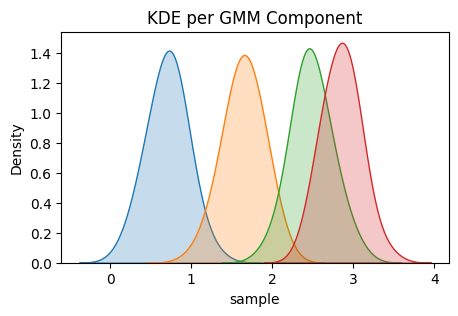

In [19]:
gmm_center, temp_data, gmm_std = gaussian_sample(num_samples, 3.5, num_centers)

In [8]:
# generate centers from DO cfc distribution
cfc_data = pd.read_csv('/home/rachel/Desktop/mm-vae data/caloric_restriction_DO_mice/cfc_data_filtered.csv')
cfc_data

,Diet,Mouse.ID,CFC.24mo.Average
0,1D,DO-1D-3001,0.84
1,1D,DO-1D-3003,83.69
2,1D,DO-1D-3010,36.71
3,1D,DO-1D-3011,21.96
4,1D,DO-1D-3013,6.93
...,...,...,...
499,AL,DO-AL-0184,25.56
500,AL,DO-AL-0185,13.73
501,AL,DO-AL-0186,20.44
502,AL,DO-AL-0188,18.31


In [9]:
round(cfc_data['CFC.24mo.Average'].max() - cfc_data['CFC.24mo.Average'].min())

97

[[-21.900215  -17.41302   -14.244028   -0.5202899  -5.500957   -7.6400056
   -4.3760023 -16.574219  -15.447731  -11.9875555]
 [  6.4695587   3.4240344   9.884343   16.552849    4.92166    14.366794
    6.4971538   6.063588   16.730528    7.357124 ]
 [ 31.94531    31.671366   30.02817    39.619144   34.10693    41.43074
   25.770407   47.629833   34.495167   30.91906  ]
 [ 50.91501    64.256424   55.407467   53.107327   72.74856    69.22845
   56.570873   70.03282    70.94914    62.472836 ]]
Standard deviation used: 14
4 10


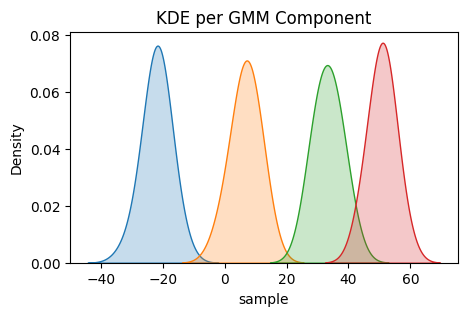

array([[-21.900215 , -17.41302  , -14.244028 ,  -0.5202899,  -5.500957 ,
         -7.6400056,  -4.3760023, -16.574219 , -15.447731 , -11.9875555],
       [  6.4695587,   3.4240344,   9.884343 ,  16.552849 ,   4.92166  ,
         14.366794 ,   6.4971538,   6.063588 ,  16.730528 ,   7.357124 ],
       [ 31.94531  ,  31.671366 ,  30.02817  ,  39.619144 ,  34.10693  ,
         41.43074  ,  25.770407 ,  47.629833 ,  34.495167 ,  30.91906  ],
       [ 50.91501  ,  64.256424 ,  55.407467 ,  53.107327 ,  72.74856  ,
         69.22845  ,  56.570873 ,  70.03282  ,  70.94914  ,  62.472836 ]],
      dtype=float32)

In [10]:
gmm_do_centers, temp_data, gmm_std = gaussian_sample(num_samples, round(cfc_data['CFC.24mo.Average'].max() - cfc_data['CFC.24mo.Average'].min()), num_centers)
gmm_do_centers

In [11]:
do_gmm_centers_df = pd.DataFrame(gmm_do_centers.T, columns = [f'center{i+1}' for i in range(num_centers)])
do_gmm_centers_df

,center1,center2,center3,center4
0,-21.900215,6.469559,31.945311,50.915009
1,-17.413019,3.424034,31.671366,64.256424
2,-14.244028,9.884343,30.028170,55.407467
3,-0.520290,16.552849,39.619144,53.107327
4,-5.500957,4.921660,34.106930,72.748558
5,-7.640006,14.366794,41.430740,69.228447
6,-4.376002,6.497154,25.770407,56.570873
7,-16.574219,6.063588,47.629833,70.032822
8,-15.447731,16.730528,34.495167,70.949142
9,-11.987556,7.357124,30.919060,62.472836


In [12]:
do_gmm_centers_df.to_csv(os.path.join(output_data_folder, 'do_gmm_centers.csv'))

[[ 91.24341   10.186772  22.94523   72.19076   11.576051  51.76738
   74.52652   66.16869   23.790562  57.844013]
 [190.84935  135.29808  123.08716  180.60233  164.97508  159.6594
  167.98677  136.34206  105.40259   99.719086]
 [258.89447  297.53214  255.73569  296.79846  293.68488  295.43628
  270.2949   288.9614   201.10342  269.7841  ]
 [347.86057  379.6775   306.8757   352.27063  315.5127   391.89136
  338.89923  344.14862  354.39215  304.8874  ]]
Standard deviation used: 250
4 10


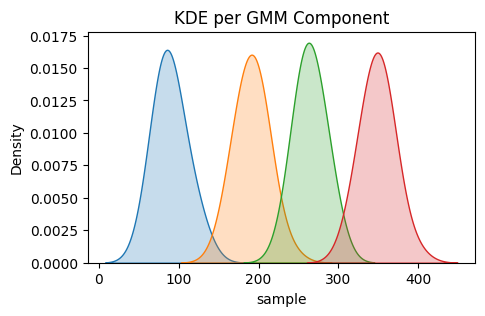

In [50]:
# make do centers with a larger range, in case they are being constrained
gmm_do_centers_spread, temp_data, gmm_std = gaussian_sample(num_samples, 400, num_centers)

In [51]:
do_gmm_centers_spread_df = pd.DataFrame(gmm_do_centers_spread.T, columns = [f'center{i+1}' for i in range(num_centers)])
do_gmm_centers_spread_df

,center1,center2,center3,center4
0,91.243408,190.849350,258.894470,347.860565
1,10.186772,135.298080,297.532135,379.677490
2,22.945230,123.087158,255.735687,306.875702
3,72.190758,180.602325,296.798462,352.270630
4,11.576051,164.975082,293.684875,315.512695
5,51.767380,159.659393,295.436279,391.891357
6,74.526520,167.986771,270.294891,338.899231
7,66.168694,136.342056,288.961395,344.148621
8,23.790562,105.402588,201.103424,354.392151
9,57.844013,99.719086,269.784088,304.887390


In [52]:
do_gmm_centers_spread_df.to_csv(os.path.join(output_data_folder, 'do_gmm_centers_spread.csv'))

Making compressed gaussian gmm centers

[[ 0.8448682  -0.77626455 -0.5210954   0.46381518 -0.74847895  0.05534757
   0.5105304   0.34337392 -0.5041888   0.17688023]
 [ 2.836987    1.7259616   1.4817432   2.6320465   2.3195016   2.213188
   2.3797352   1.746841    1.1280518   1.0143816 ]
 [ 4.1978893   4.9706426   4.1347136   4.955969    4.8936973   4.9287257
   4.425898    4.799228    3.0420685   4.415682  ]
 [ 5.9772115   6.6135497   5.157514    6.0654125   5.330254    6.857827
   5.7979846   5.902972    6.107843    5.1177473 ]]
Standard deviation used: 0.5
4 10


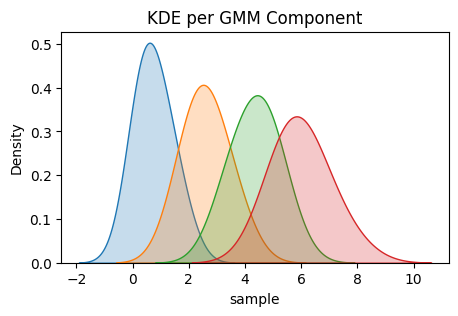

In [ ]:
# make do centers with a larger range, in case they are being constrained
gmm_do_centers_comp, temp_data, gmm_std = gaussian_sample(num_samples, 10, num_centers)

In [18]:
do_gmm_centers_comp_df = pd.DataFrame(gmm_do_centers_comp.T, columns = [f'center{i+1}' for i in range(num_centers)])
do_gmm_centers_comp_df

,center1,center2,center3,center4
0,0.844868,2.836987,4.197889,5.977211
1,-0.776265,1.725962,4.970643,6.613550
2,-0.521095,1.481743,4.134714,5.157514
3,0.463815,2.632046,4.955969,6.065413
4,-0.748479,2.319502,4.893697,5.330254
5,0.055348,2.213188,4.928726,6.857827
6,0.510530,2.379735,4.425898,5.797985
7,0.343374,1.746841,4.799228,5.902972
8,-0.504189,1.128052,3.042068,6.107843
9,0.176880,1.014382,4.415682,5.117747


In [ ]:
do_gmm_centers_comp_df.to_csv(os.path.join(output_data_folder, 'do_gmm_centers_comp.csv'))

Making gaussian center ranges even smaller to encourage continuity in the latent space

[[-4.9541755 -4.767209  -4.6351676 -4.0633454 -4.270873  -4.36
  -4.224     -4.7322593 -4.6853223 -4.541148 ]
 [-3.7721016 -3.8989985 -3.629819  -3.3519647 -3.8365974 -3.4430501
  -3.770952  -3.7890172 -3.3445613 -3.7351198]
 [-2.710612  -2.7220263 -2.790493  -2.390869  -2.6205447 -2.3153858
  -2.9678998 -2.0570903 -2.6043682 -2.7533724]
 [-1.920208  -1.3643155 -1.7330222 -1.8288614 -1.0104767 -1.1571481
  -1.684547  -1.1236324 -1.0854524 -1.4386319]]
Standard deviation used: 0.05
4 10


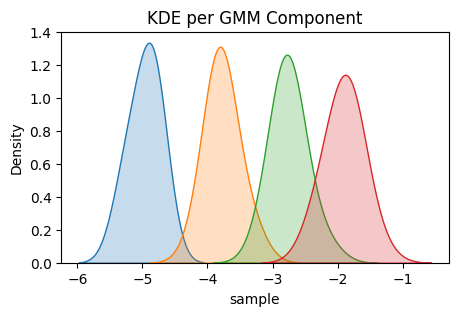

In [76]:
# make do centers with a larger range, in case they are being constrained
gmm_do_centers_range5, temp_data, gmm_std = gaussian_sample(num_samples, 5, num_centers)

In [28]:
do_gmm_centers_range5_df = pd.DataFrame(gmm_do_centers_range5.T, columns = [f'center{i+1}' for i in range(num_centers)])
do_gmm_centers_range5_df

,center1,center2,center3,center4
0,-4.480080,-3.193489,-2.313143,-1.059737
1,-4.262962,-3.802965,-2.568703,-1.051126
2,-4.079229,-3.376845,-2.336612,-1.875375
3,-4.099953,-3.492877,-2.333107,-1.673817
4,-4.302792,-3.445588,-2.808160,-1.335071
5,-4.620855,-3.251865,-2.825973,-1.430895
6,-4.593925,-3.166275,-2.696125,-1.789817
7,-4.214241,-3.393338,-2.677751,-1.558214
8,-4.324373,-3.488826,-2.206264,-1.040168
9,-4.264039,-3.341149,-2.716214,-1.336146


In [29]:
do_gmm_centers_range5_df.to_csv(os.path.join(output_data_folder, 'do_gmm_centers_range5.csv'))

Making even more compressed gaussian centers

[[0.8022351  0.7873745  0.22243372 0.7953455  0.32826194 0.64148176
  0.9392371  0.9625343  0.72854507 0.38519543]
 [1.864064   1.1080956  1.8165866  1.2275954  1.864353   1.3996783
  1.1153418  1.2654663  1.3136773  1.576588  ]
 [2.8107493  2.8721669  2.4603033  2.0236645  2.9668891  2.9811497
  2.9704006  2.1084025  2.6062088  2.2547226 ]
 [3.2668056  3.8585932  3.3051908  3.1931298  3.279125   3.5362158
  3.178568   3.4345639  3.511423   3.7087853 ]]
Standard deviation used: 0.08
4 10


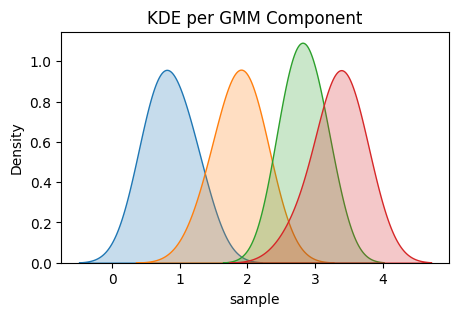

In [91]:
gmm_do_centers_range4, temp_data, gmm_std = gaussian_sample(num_samples, 4, num_centers)

In [92]:
do_gmm_centers_range4_df = pd.DataFrame(gmm_do_centers_range4.T, columns = [f'center{i+1}' for i in range(num_centers)])
do_gmm_centers_range4_df

,center1,center2,center3,center4
0,0.802235,1.864064,2.810749,3.266806
1,0.787374,1.108096,2.872167,3.858593
2,0.222434,1.816587,2.460303,3.305191
3,0.795345,1.227595,2.023664,3.193130
4,0.328262,1.864353,2.966889,3.279125
5,0.641482,1.399678,2.981150,3.536216
6,0.939237,1.115342,2.970401,3.178568
7,0.962534,1.265466,2.108402,3.434564
8,0.728545,1.313677,2.606209,3.511423
9,0.385195,1.576588,2.254723,3.708785


In [93]:
do_gmm_centers_range4_df.to_csv(os.path.join(output_data_folder, 'do_gmm_centers_range4.csv'))

Make more compressed centers (range 2 instead of 4)

[[-2.7400398 -2.6314812 -2.5396147 -2.5499766 -2.6513958 -2.8104274
  -2.7969625 -2.6071205 -2.6621864 -2.6320193]
 [-2.0967445 -2.4014823 -2.1884222 -2.2464387 -2.2227938 -2.1259327
  -2.0831375 -2.196669  -2.244413  -2.1705747]
 [-1.6565714 -1.7843513 -1.6683062 -1.6665535 -1.9040799 -1.9129863
  -1.8480625 -1.8388754 -1.6031322 -1.8581069]
 [-1.0298685 -1.0255628 -1.4376874 -1.3369086 -1.1675353 -1.2154474
  -1.3949087 -1.279107  -1.020084  -1.168073 ]]
Standard deviation used: 0.05
4 10


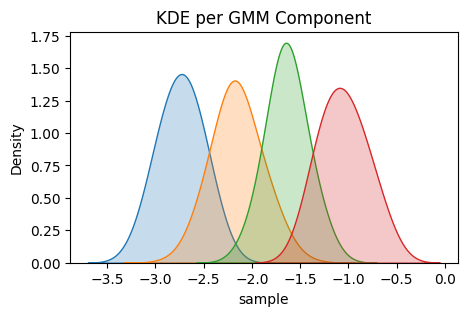

In [20]:
gmm_do_centers_range2, temp_data, gmm_std = gaussian_sample(num_samples, 2, num_centers)

In [21]:
do_gmm_centers_range2_df = pd.DataFrame(gmm_do_centers_range2.T, columns = [f'center{i+1}' for i in range(num_centers)])
do_gmm_centers_range2_df

,center1,center2,center3,center4
0,-2.740040,-2.096745,-1.656571,-1.029868
1,-2.631481,-2.401482,-1.784351,-1.025563
2,-2.539615,-2.188422,-1.668306,-1.437687
3,-2.549977,-2.246439,-1.666553,-1.336909
4,-2.651396,-2.222794,-1.904080,-1.167535
5,-2.810427,-2.125933,-1.912986,-1.215447
6,-2.796962,-2.083138,-1.848063,-1.394909
7,-2.607121,-2.196669,-1.838875,-1.279107
8,-2.662186,-2.244413,-1.603132,-1.020084
9,-2.632019,-2.170575,-1.858107,-1.168073


In [22]:
do_gmm_centers_range2_df.to_csv(os.path.join(output_data_folder, 'do_gmm_centers_range2.csv'))

Make 6 gaussian centers for DO mice dataset

[[-0.43137053 -0.7353539  -0.31062886 -0.92882025 -0.80218077 -0.940362
  -0.53130203 -0.40196332 -0.32570162 -0.42375302]
 [ 0.0602303   0.08118746  0.46991247  0.2334238   0.11477631  0.7926286
   0.3040912   0.8894229   0.86051685  0.763109  ]
 [ 1.9601088   1.2398652   1.0326399   1.2645546   1.2248094   1.595044
   1.4025085   1.7345339   1.5871229   1.1751907 ]
 [ 2.0992336   2.5519922   2.2881048   2.7912478   2.1489894   2.8242402
   2.2722461   2.6037138   2.0207455   2.5189638 ]
 [ 3.762737    3.1565325   3.2827184   3.5897896   3.2656324   3.9211926
   3.5399816   3.0258648   3.7647605   3.4422295 ]
 [ 4.625515    4.4085174   4.8596067   4.8039055   4.142236    4.4391537
   4.437759    4.2289243   4.821421    4.2781568 ]]
Standard deviation used: 0.08
6 10


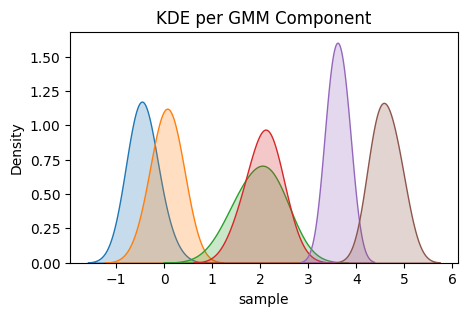

In [106]:
gmm_do_6centers_range4, temp_data, gmm_std = gaussian_sample(num_samples, 6, num_centers)

In [102]:
do_gmm_6centers_range4_df = pd.DataFrame(gmm_do_6centers_range4.T, columns = [f'center{i+1}' for i in range(num_centers)])
do_gmm_6centers_range4_df

,center1,center2,center3,center4,center5,center6
0,0.219422,1.435836,2.029025,3.336129,4.679142,5.404317
1,0.165045,1.467390,2.127628,3.622257,4.026967,5.394020
2,0.564392,1.027102,2.642750,3.135700,4.461699,5.050285
3,0.379104,1.211660,2.326846,3.761230,4.379126,5.752010
4,0.831924,1.252272,2.081906,3.019383,4.539419,5.999908
5,0.349960,1.650144,2.781233,3.651755,4.754233,5.949612
6,0.199361,1.020380,2.152382,3.126221,4.669459,5.563970
7,0.217965,1.699465,2.766898,3.167789,4.607247,5.747926
8,0.114533,1.819301,2.964721,3.108099,4.025679,5.311957
9,0.677347,1.958173,2.396654,3.715015,4.075996,5.690614


In [103]:
do_gmm_6centers_range4_df.to_csv(os.path.join(output_data_folder, 'do_gmm_6centers_range4.csv'))

Make 8 gaussian centers for DO dataset

[[0.5382206  0.6688736  0.5918928  0.45469934 0.7490243  0.24728331
  0.2562437  0.57868475 0.83057165 0.04106913]
 [1.734634   1.7981423  1.6629997  1.3375006  1.0520856  1.8392289
  1.3688952  1.9288871  1.2428493  1.5327452 ]
 [2.799868   2.7241814  2.0839474  2.87964    2.9519198  2.6213357
  2.6058927  2.5757968  2.697193   2.6615214 ]
 [3.8978114  3.8405056  3.4286127  3.2782567  3.2242222  3.238545
  3.9637346  3.9080262  3.3015826  3.0689569 ]
 [4.4882293  4.919542   4.8668513  4.9512043  4.0686183  4.4735613
  4.718357   4.375307   4.684259   4.6475434 ]
 [5.2729354  5.980722   5.181729   5.421565   5.9572854  5.1143894
  5.777792   5.9414706  5.805528   5.012652  ]
 [6.485642   6.5341234  6.260156   6.834911   6.040258   6.9477572
  6.163766   6.19833    6.796227   6.4200587 ]
 [7.3888574  7.906929   7.3273525  7.470307   7.03103    7.465034
  7.311039   7.5920978  7.5659328  7.4902015 ]]
Standard deviation used: 0.05
8 10


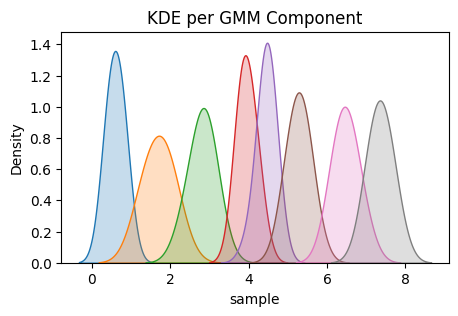

In [17]:
gmm_do_8centers, temp_data, gmm_std = gaussian_sample(num_samples, 8, num_centers)

In [18]:
do_gmm_8centers_df = pd.DataFrame(gmm_do_8centers.T, columns = [f'center{i+1}' for i in range(num_centers)])
do_gmm_8centers_df

,center1,center2,center3,center4,center5,center6,center7,center8
0,0.538221,1.734634,2.799868,3.897811,4.488229,5.272935,6.485642,7.388857
1,0.668874,1.798142,2.724181,3.840506,4.919542,5.980722,6.534123,7.906929
2,0.591893,1.663000,2.083947,3.428613,4.866851,5.181729,6.260156,7.327353
3,0.454699,1.337501,2.879640,3.278257,4.951204,5.421565,6.834911,7.470307
4,0.749024,1.052086,2.951920,3.224222,4.068618,5.957285,6.040258,7.031030
5,0.247283,1.839229,2.621336,3.238545,4.473561,5.114389,6.947757,7.465034
6,0.256244,1.368895,2.605893,3.963735,4.718357,5.777792,6.163766,7.311039
7,0.578685,1.928887,2.575797,3.908026,4.375307,5.941471,6.198330,7.592098
8,0.830572,1.242849,2.697193,3.301583,4.684259,5.805528,6.796227,7.565933
9,0.041069,1.532745,2.661521,3.068957,4.647543,5.012652,6.420059,7.490201


In [20]:
do_gmm_8centers_df.to_csv(os.path.join(output_data_folder, 'do_gmm_8centers.csv'))

Make offset centers for DO mice dataset

In [47]:
offset_do = gmm_std / 2
do_centers_geno = do_gmm_centers_df - offset_do
do_centers_geno

,center1,center2,center3,center4
0,-28.900215,-0.530441,24.945311,43.915009
1,-24.413019,-3.575966,24.671366,57.256424
2,-21.244028,2.884343,23.028170,48.407467
3,-7.520290,9.552849,32.619144,46.107327
4,-12.500957,-2.078340,27.106930,65.748558
5,-14.640005,7.366794,34.430740,62.228447
6,-11.376002,-0.502846,18.770407,49.570873
7,-23.574219,-0.936412,40.629833,63.032822
8,-22.447731,9.730528,27.495167,63.949142
9,-18.987556,0.357124,23.919060,55.472836


In [49]:
do_centers_geno.to_csv(os.path.join(output_data_folder, 'do_centers_geno.csv'))

In [48]:
do_centers_physio = do_gmm_centers_df + offset_do
do_centers_physio

,center1,center2,center3,center4
0,-14.900215,13.469559,38.945312,57.915009
1,-10.413019,10.424034,38.671364,71.256424
2,-7.244028,16.884342,37.028168,62.407467
3,6.479710,23.552849,46.619144,60.107327
4,1.499043,11.921659,41.106930,79.748558
5,-0.640006,21.366795,48.430740,76.228447
6,2.623998,13.497154,32.770409,63.570873
7,-9.574219,13.063588,54.629833,77.032822
8,-8.447731,23.730528,41.495167,77.949142
9,-4.987556,14.357124,37.919060,69.472839


In [50]:
do_centers_physio.to_csv(os.path.join(output_data_folder, 'do_centers_physio.csv'))

Generate offset priors

In [12]:
priors_from_QRT = pd.read_csv('/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/gmm_centers_4gaussian_14mon_fromQRT.csv')
priors_from_QRT = priors_from_QRT.iloc[:, 1:]
priors_from_QRT

,center1,center2,center3,center4
0,-30.585873,-24.462252,-16.610109,-9.414127
1,-25.841194,-17.934853,-11.602342,-5.269917
2,-24.079937,-17.285593,-7.169091,1.857715
3,-21.629989,-10.992317,-3.562923,8.296656
4,-17.591695,-5.133384,4.086609,13.147251
5,-14.035831,-4.087272,6.559461,18.480276
6,-12.060919,0.341399,11.852517,25.394252
7,-7.304223,4.101179,16.558175,29.526446
8,-6.641201,7.976209,25.043630,37.752312
9,-2.612398,13.501478,30.240794,42.612398


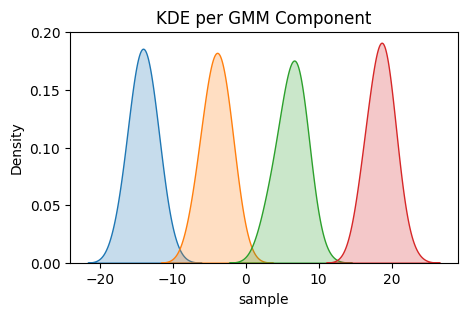

In [13]:
samples, components = draw_gmm_samples(400, torch.tensor(priors_from_QRT.values.T).float(), 3)
data = samples.numpy()
df = pd.DataFrame({'sample': data[:, 5], 'component': components})
plt.figure(figsize=(5, 3))
for comp_id in sorted(df['component'].unique()):
    subset = df[df['component'] == comp_id]
    sns.kdeplot(x=subset['sample'], fill=True, label=f'Component {comp_id}',bw_adjust=2)
plt.title("KDE per GMM Component")
plt.show()

In [14]:
gmm_std = 2
offset = gmm_std / 2
hc_priors = priors_from_QRT - offset
hc_priors

,center1,center2,center3,center4
0,-31.585873,-25.462252,-17.610109,-10.414127
1,-26.841194,-18.934853,-12.602342,-6.269917
2,-25.079937,-18.285593,-8.169091,0.857715
3,-22.629989,-11.992317,-4.562923,7.296656
4,-18.591695,-6.133384,3.086609,12.147251
5,-15.035831,-5.087272,5.559461,17.480276
6,-13.060919,-0.658601,10.852517,24.394252
7,-8.304223,3.101179,15.558175,28.526446
8,-7.641201,6.976209,24.043630,36.752312
9,-3.612398,12.501478,29.240794,41.612398


In [15]:
pfc_priors = priors_from_QRT + offset
pfc_priors

,center1,center2,center3,center4
0,-29.585873,-23.462252,-15.610109,-8.414127
1,-24.841194,-16.934853,-10.602342,-4.269917
2,-23.079937,-16.285593,-6.169091,2.857715
3,-20.629989,-9.992317,-2.562923,9.296656
4,-16.591695,-4.133384,5.086609,14.147251
5,-13.035831,-3.087272,7.559461,19.480276
6,-11.060919,1.341399,12.852517,26.394252
7,-6.304223,5.101179,17.558175,30.526446
8,-5.641201,8.976209,26.043630,38.752312
9,-1.612398,14.501478,31.240794,43.612398


In [16]:
hc_priors.to_csv('/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/HC_priors_0.5std.csv')

In [17]:
pfc_priors.to_csv('/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/PFC_priors_0.5std.csv')